In [27]:
from LiouvilleLanczos.Quantum_computer.Hamiltonian import Line_Hubbard, BoundaryCondition
from qiskit_nature.second_q.operators import FermionicOp
from LiouvilleLanczos.Quantum_computer.QC_lanczos import Liouvillian_spo, sum_spo, relative_simplify_spo, separate_imag, dump_qpu_error , inner_product_spo
from qiskit_ibm_runtime import RuntimeJobFailureError
from typing import Optional
from LiouvilleLanczos.Lanczos import Lanczos as LCZ
import numpy as np
from qiskit.circuit.library import real_amplitudes
from qiskit_aer.primitives import EstimatorV2 as AerEstimatorV2
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from LiouvilleLanczos.Green import CF_Green, PolyLehmann_Green, Green_matrix
from LiouvilleLanczos.Lanczos_components import Inner_product as Base_inner_product
from qiskit.primitives import BaseEstimatorV2
from qiskit.circuit.library import UnitaryGate
import matplotlib.pyplot as plt
from qiskit.quantum_info import Operator

MAPPER = JordanWignerMapper()

In [28]:
def to_sparse_pauli(op):
    """
    Convert FermionicOp -> SparsePauliOp.
    Leave SparsePauliOp unchanged.
    """
    if isinstance(op, SparsePauliOp):
        return op

    if isinstance(op, FermionicOp):
        return MAPPER.map(op).simplify(atol=1e-12)

    raise TypeError(f"Unsupported operator type: {type(op)}")

def exact_gs_circuit_two_sites():
    bt = 0.7854074074074073
    GS_analytical = QuantumCircuit(4)
    GS_analytical.h(0)
    GS_analytical.x(1)
    GS_analytical.cx(0,1)
    GS_analytical.ry(bt,2)
    GS_analytical.x(3)
    GS_analytical.cx(2,3)
    GS_analytical.cx(1,3)
    GS_analytical.cx(1,2)
    GS_analytical.cz(1,2)
    GS_analytical.swap(1,2)
    return GS_analytical

def apply_adjacent_fswap_permutation(qc, fswap_gate):
    #perm = [3,4,5,0,1,2]
    perm = [5,6,7,8,9,0,1,2,3,4]
    current = list(range(len(perm)))                # this just makes a list [0,1,2,3,4,5,...]
    for target_pos, desired_mode in enumerate(perm):        # this chooses the desired position and target position
        j = current.index(desired_mode)                     # find the index of the desired mode

        while j > target_pos:                               # while the index of the desired mode is larger than the target position
            qc.append(fswap_gate, [j - 1, j])               # swap it with the qubit to the left of it 
            current[j - 1], current[j] = current[j], current[j - 1] #update indices
            j -= 1                                                          


In [29]:
def hubbard(hop=np.array([[0, 1], [1, 0]]), u=4, mu=None):
    n = len(hop)
    if mu is None:
        mu = u / 2
    hopping = FermionicOp(
        {
            f"+_{i+m} -_{j+m}": hop[i, j]
            for m in [0, n]
            for i in range(n)
            for j in range(n)
            if hop[i, j] != 0
        },
        num_spin_orbitals=2 * n,
    )
    occupation = FermionicOp(
        {f"+_{i} -_{i}": 1 for i in range(2 * n)}, num_spin_orbitals=2 * n
    )
    interaction = FermionicOp(
        {f"+_{i} +_{i+n} -_{i+n} -_{i}": 1 for i in range(n)}, num_spin_orbitals=2 * n
    )
    HH = -hopping + u * interaction - mu * occupation
    return MAPPER.map(-hopping + u * interaction - mu * occupation), HH



In [30]:
# U = 4 
# q = 6

# n = int(q/2)

# hopping = np.diag(np.ones(n - 1), 1) + np.diag(np.ones(n - 1), -1)

# hamiltonian, HH = hubbard(hopping, U, mu=U/2)
# C0 = FermionicOp(
#     {
#         "+_0": 1,
#     },
#     num_spin_orbitals=q,
# )
# C0 = MAPPER.map(C0)



# vqe_hubbard_3sites = real_amplitudes(num_qubits=q, reps=11, entanglement='linear')
# vqe_hubbard_3sites = vqe_hubbard_3sites.assign_parameters(np.array([
#     5.246829583426229, 1.8445563598975319, 6.249341224922228, 5.547426630865061, 4.204112886091582,
#     4.7123853975763605, 0.27755320293694075, 0.32924783165591026, 1.5501725153481376, 0.354654347037912,
#     1.4126950505240836, 7.524339982913663e-06, 1.5454883723953319, 4.008676262413297, 0.5471153440483539,
#     0.6439116484454839, 5.416150750408826, 3.141590029386429, 1.121133004167295, 4.919561698711213,
#     4.354025416990712, 4.348236205036469, 0.1627483139705849, 6.890458045940891e-06, 1.5750620500544459,
#     3.925552761663296, 2.4735512439001406, 3.564021121427497, 2.1847082492649674, 3.1415875290047737,
#     5.145406231818936, 3.082671747231, 4.755880471423207, 1.5314536798535008, 5.823307617043694,
#     3.1416008591215223, 5.901892324799543, 1.4437881974849553, 4.645825634069647, 1.6387913496744664,
#     5.2749649006268555, 1.1584242198623043e-05, 2.4788427008935474, 5.261826591438184, 5.982045041499495,
#     2.24084148657242, 1.3918515401467277, 3.141590524117431, 2.6212585750135275, 0.0, 4.140488402169957,
#     0.6887497275343819, 0.16071147559368984, 4.712382212081382, 5.6131238667553776, 0.2442058266515827,
#     2.815716430300995, 1.696363607754504, 4.71239011907928, 6.283185307179586, 2.0669264858298853,
#     2.441456446485303, 1.273233624886327, 2.646377569674503, 0.957628396457077, 1.8447208439653136,
#     5.224543370694376, 1.583011829806925, 6.116083873171027, 6.0304071284479774e-06, 1.570785721175754,
#     2.9229147479846883e-06
# ]))


In [32]:
n = 5
U = 4
hopping = np.diag(np.ones(n - 1), 1) + np.diag(np.ones(n - 1), -1)
hamiltonian, HH = hubbard(hopping, U, mu=U/4)
h_mu = (U/4) * np.diag(np.ones(n))
eigvals, eigvecs = np.linalg.eigh(hamiltonian.to_matrix())


vqe_hubbard_5sites = real_amplitudes(num_qubits=10, reps=10, entanglement='linear')
vqe_hubbard_5sites = vqe_hubbard_5sites.assign_parameters(np.array([
    2.3447832964919617, 1.4474302559938388, 4.713514444810458, 4.483509407584665, 4.400570018376737,
    3.1599828310535765, 1.4811927345460485, 4.401225733572901, 4.9385281687492535, 4.712960988556388,
    3.9345915095063786, 4.798725490293983, 1.6957962772935746, 4.18431690489243, 1.4314151293812927,
    3.6586171333767994, 2.0421913767282662, 4.861557641736541, 4.7384698726472285, 3.734752714234186,
    5.6471486574706375, 4.711408611937339, 4.747181489931575, 4.785705709657881, 5.773891260485987,
    3.164130952306159, 5.87030802541217, 4.62641468296399, 1.5715680039711153, 3.17431807296486,
    0.5479225386262592, 4.7125194894458895, 1.5707646540418294, 1.5708020948979795, 4.712386411886244,
    1.5707956120001854, 1.570800746348143, 4.712386246353408, 6.283183592137927, 6.283185024020641,
    6.283108640215091, -0.31483874554879887, 2.5684582292450258, 6.641278834606595, 1.595865508133264,
    3.5586234337709435, 1.6436999282262008, 1.5707985348741194, -2.0956374394721885e-06, -0.3551216158824308,
    3.1415901265735933, 4.413018428808857, 5.313840134725547, 4.478621591268556, 3.109855048054034,
    6.519653639112034, -0.14634612324162952, 4.712390805311075, 0.2152617755934342, 7.820990358428639,
    3.141596566559733, 4.315707796787452, 1.591058317291354, 1.5511314469306399, 4.654357447200541,
    4.708047365972247, 1.5707966504313826, 4.712389377489952, 4.710279668850846, 4.739490027393471,
    3.14158387406988, 4.71821903393061, 4.752704332942756, 4.680290507834347, 1.3224139337263787,
    3.6174009369047324, 1.5707939141135263, 1.5335737771548246, 4.690684139651661, 1.5408585947576945,
    9.324079134959437e-06, 1.6182910007664684, 1.6703109721089433, 1.4147301236346137, 1.5740252318995949,
    1.5707960492817332, 1.570798283653272, 1.5191349714558515, 1.6161172741980936, -0.31862288861427424,
    1.5707879571326253, 6.165949907011652, 6.6176881469443485, 1.2673449170192668, 3.6129609342647377,
    3.1415932962911555, 5.9963476937642755, 2.8726739404577013, 4.769961554828166, 2.9322930511089185,
    1.5707945163585162, 4.712389541091441, 4.712391063980809, 1.5707945358999216, 1.5707993205185902,
    4.7123863681724245, 1.5707962675025136, 4.712390122552536, 4.712389940305301, 4.712388510339969
]))

In [33]:
FSWAP = np.array([
            [1, 0, 0,  0],
            [0, 0, -1,  0],
            [0, 1, 0,  0],
            [0, 0, 0, 1],
        ], dtype=complex)
fswap_gate = UnitaryGate(FSWAP, label="FSWAP")

print("F^dag @ F = I? " , np.allclose(FSWAP.conj().T @ FSWAP, np.eye(4)))

F^dag @ F = I?  True


In [35]:
F_circ = QuantumCircuit(10)
apply_adjacent_fswap_permutation(F_circ, fswap_gate)

F = Operator(F_circ).data
H = hamiltonian.to_matrix()


print(np.allclose(F.conj().T @ H @ F, H, atol=1e-10))
print(np.linalg.norm(F.conj().T @ H @ F - H))

True
0.0


In [36]:
GS1 = vqe_hubbard_5sites.copy()

GS2 = GS1.copy()


apply_adjacent_fswap_permutation(GS2, fswap_gate)

In [37]:
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import Statevector
estimator = StatevectorEstimator()

res1 = estimator.run([(GS1,hamiltonian)])
res2 = estimator.run([(GS2,hamiltonian)])

SG1 = Statevector(GS1).data
SG2 = Statevector(GS2).data
print("orthogonal:" , np.allclose(SG1.T @ SG2, 0, atol=1e-10))
print("energies of 2 ground states equal?",np.allclose(res1.result()[0].data.evs,res2.result()[0].data.evs, atol=1e-10))


orthogonal: True
energies of 2 ground states equal? True


# Galitskii migdal transplant code

In [38]:
from LiouvilleLanczos.matrix_impl import (
    MatrixState_inner_product,
    Matrix_Liouvillian,
    Matrix_sum,
)

In [39]:
def annihilation_operators(n):
    c_fermi_list = [
        FermionicOp({f"-_{i}": 1}, num_spin_orbitals=2 * n) for i in range(n)
    ]
    return [MAPPER.map(c) for c in c_fermi_list]

def annihilation_operators_down(n):
    c_fermi_list = [
        FermionicOp({f"-_{i+n}": 1}, num_spin_orbitals=2 * n) for i in range(n)
    ]
    return [MAPPER.map(c) for c in c_fermi_list]

In [40]:
def get_abmu(ground_state, max_iter=10, n=4, opset="0-123", down=False):
    if down:
        c_operators = annihilation_operators_down(n)
    else:
        c_operators = annihilation_operators(n)
    
    main_i, other_i = opset.split("-")
    main_op = c_operators[int(main_i)]
    other_ops = [c_operators[int(i)] for i in other_i]

    lanczos = LCZ(
        MatrixState_inner_product(ground_state),
        Matrix_Liouvillian(),
        Matrix_sum(),
        logger=None,
    )
    a, b, mm = lanczos.polynomial_hybrid(
        hamiltonian.to_matrix(),
        main_op.to_matrix(),
        [o.to_matrix() for o in other_ops],
        max_iter,
    )
    return a, b, mm

In [41]:
# opset = ["0-12", "1-"]
# green_mapping = [
#     (0, 0, 0, 1),
#     (2, 2, 0, 1),
#     (0, 1, 1, 1),
#     (1, 0, 1, 1),
#     (1, 2, 1, 1),
#     (2, 1, 1, 1),
#     (0, 2, 2, 1),
#     (2, 0, 2, 1),
#     (1, 1, 3, 1),
# ]


opset = ["0-1234", "1-23", "2-"]
green_mapping = [
    (0, 0, 0, 1),
    (4, 4, 0, 1),
    (0, 1, 1, 1),
    (0, 1, 1, 1),
    (3, 4, 1, 1),
    (4, 3, 1, 1),
    (0, 2, 2, 1),
    (2, 0, 2, 1),
    (2, 4, 2, 1),
    (4, 2, 2, 1),
    (0, 3, 3, 1),
    (3, 0, 3, 1),
    (1, 4, 3, 1),
    (4, 1, 3, 1),
    (0, 4, 4, 1),
    (4, 0, 4, 1),
    (1, 1, 5, 1),
    (3, 3, 5, 1),
    (1, 2, 6, 1),
    (2, 1, 6, 1),
    (2, 3, 6, 1),
    (3, 2, 6, 1),
    (1, 3, 7, 1),
    (3, 1, 7, 1),
    (2, 2, 8, 1),
]

In [42]:
def make_green_list(a, b, mm, min_iter=1):
    mm = np.asarray(mm)
    num_iterations = len(a)
    num_k = max(num_iterations, min_iter)
    num_moments = len(mm[0])
    green_list = np.empty((num_k, num_moments + 1), dtype=object)
    for k in range(1, num_k + 1):
        kk = min(
            k, num_iterations
        )  ## fill the k > num_iteration with the converged CF_Green
        green_list[k - 1, 0] = CF_Green(a[:kk], b[:kk])
        green0 = green_list[k - 1, 0].to_Lehmann()
        for m in range(num_moments):
            green_list[k - 1, m + 1] = PolyLehmann_Green(
                a[:k], b[:k], mm[:k, m], green0
            )
    return green_list

In [43]:
def make_green_stack(ground_state, opset_list=["0-123", "1-2"], max_iter=10, n=4, down=False):
    stacked_green = None
    abm_dict = {}
    min_iter = 1
    for opset in opset_list:
        a, b, m = get_abmu(ground_state, max_iter, n, opset, down=down)
        abm_dict[opset] = (a, b, m)
        min_iter = max(min_iter, len(a))

    for opset, (a, b, m) in abm_dict.items():
        green_list = make_green_list(a, b, m, min_iter)
        if stacked_green is None:
            stacked_green = green_list
        else:
            stacked_green = np.hstack(
                [stacked_green, green_list]
            )  # si ça converge plus vite que le critere on a un probleme
    return stacked_green  # 6 Green par 30it

In [44]:
eigvals, eigvecs = np.linalg.eigh(hamiltonian.to_matrix())
degen_gs_vectors = eigvecs[:,(eigvals-eigvals.min())<1e-9].T

In [45]:
greens = []
for down in [True, False]:

    degen_gm_energies = []
    for gs_vector in degen_gs_vectors:

        true_stack_green = make_green_stack(gs_vector, opset, 31, n, down=down)
        green = true_stack_green
        num_iterations = len(green)

    greens.append(true_stack_green[-1,0])

In [48]:
C0 = FermionicOp(
    {
        "+_0": 1,
    },
    num_spin_orbitals=10,
)
C0 = MAPPER.map(C0)

In [49]:
eps = 1e-6
kmax = 10
lanczos1 = LCZ(inner_product_spo(GS1,AerEstimatorV2(),eps),Liouvillian_spo(eps),sum_spo(eps))
lanczos2 = LCZ(inner_product_spo(GS2,AerEstimatorV2(),eps),Liouvillian_spo(eps),sum_spo(eps))

lanczos_result1 = lanczos1(hamiltonian,C0,kmax,1e-8)
lanczos_result2 = lanczos2(hamiltonian,C0,kmax,1e-8)


KeyboardInterrupt: 

/Users/asaad/Documents/Algolabs/Liouville-Lanczos/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/asaad/Documents/Algolabs/Liouville-Lanczos/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


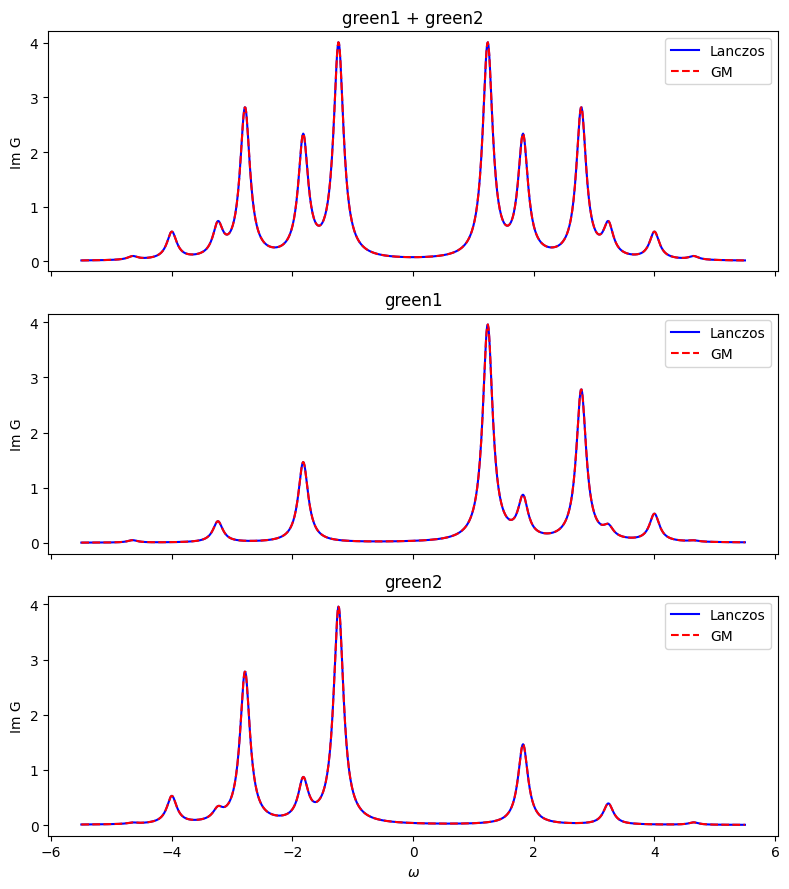

In [ ]:
green1  = CF_Green(lanczos_result1[0], lanczos_result1[1])
green2  = CF_Green(lanczos_result2[0], lanczos_result2[1])

w = np.linspace(-5.5,5.5,1000)-1e-1j
x = np.real(w)

fig, axs = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

axs[0].plot(x, (np.imag(green1(w))+ np.imag(green2(w))), color="blue", label = "Lanczos")
axs[0].plot(w, np.imag(greens[0](w))+np.imag(greens[1](w)), label = "GM", color = "red", linestyle = "--")
axs[0].set_title("green1 + green2")
axs[0].set_ylabel("Im G")
axs[0].legend()

axs[1].plot(x, np.imag(green1(w)), color="blue", label = "Lanczos")
axs[1].plot(w, np.imag(greens[0](w)), label = "GM", color = "red", linestyle = "--")
axs[1].set_title("green1")
axs[1].set_ylabel("Im G")
axs[1].legend()

axs[2].plot(x, np.imag(green2(w)), color="blue", label = "Lanczos")
axs[2].plot(w, np.imag(greens[1](w)), label = "GM", color = "red", linestyle = "--")
axs[2].set_title("green2")
axs[2].set_ylabel("Im G")
axs[2].set_xlabel(r"$\omega$")
axs[2].legend()
plt.tight_layout()
plt.show()